In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

# Rinominata MHA per evitare conflitto con keras.layers.MultiHeadAttention
class MHA(nn.Module):
    def __init__(self, d_model, h):
        super().__init__()
        assert d_model % h == 0
        self.h, self.d_model, self.d_k = h, d_model, d_model // h
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        B, S, _ = x.size()
        return x.view(B, S, self.h, self.d_k).transpose(1, 2)

    def forward(self, Q, K, V):
        B = Q.size(0)
        Q, K, V = self.split_heads(self.W_Q(Q)), self.split_heads(self.W_K(K)), self.split_heads(self.W_V(V))
        out, w = scaled_dot_product_attention(Q, K, V)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.d_model)
        return self.W_O(out), w


In [8]:
class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )
    def forward(self, x):
        return self.net(x)

class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, h):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.mhsa  = MHA(d_model, h)
        self.ffn   = FeedForward(d_model)

    def forward(self, x):
        normed = self.norm1(x)
        attn_out, weights = self.mhsa(normed, normed, normed)
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return x, weights


In [9]:
# ── Iperparametri ──────────────────────────────────────────────
H, W, C   = 8, 8, 3    # immagine 8×8 RGB
P         = 2           # patch 2×2
N         = (H * W) // (P * P)   # 16 patch
d_model   = 8
num_heads = 2
L         = 2           # blocchi encoder
num_cls   = 3           # classi: cane / gatto / uccello

# ── Step 1: immagine sintetica + Patch Extraction ──────────────
img = torch.randn(1, C, H, W)
ph, pw = H // P, W // P

x = img.unfold(2, P, P).unfold(3, P, P)        # (1, C, ph, pw, P, P)
x = x.contiguous().view(1, C, N, P * P)         # (1, C, N, P²)
x = x.permute(0, 2, 1, 3).contiguous().view(1, N, C * P * P)
print(f"Step 1 — patch estratte:  {x.shape}")   # (1, 16, 12)

# ── Step 2: Linear Embedding ───────────────────────────────────
patch_emb = nn.Linear(C * P * P, d_model)
x = patch_emb(x)
print(f"Step 2 — dopo embedding:  {x.shape}")   # (1, 16, 8)

# ── Step 3: Prepend [CLS] token ────────────────────────────────
cls_token = nn.Parameter(torch.randn(1, 1, d_model))
x = torch.cat([cls_token.expand(1, -1, -1), x], dim=1)
print(f"Step 3 — con [CLS]:       {x.shape}")   # (1, 17, 8)

# ── Step 4: Positional Embedding ───────────────────────────────
pos_emb = nn.Parameter(torch.randn(1, N + 1, d_model))
x = x + pos_emb
print(f"Step 4 — pos. encoding:   {x.shape}")   # (1, 17, 8)

# ── Step 5: L Transformer Encoder Blocks ───────────────────────
encoder = [TransformerEncoderBlock(d_model, num_heads) for _ in range(L)]
all_weights = []
for l, block in enumerate(encoder):
    x, w = block(x)
    all_weights.append(w)
    print(f"Step 5 — Block {l+1} output:   {x.shape}")

# ── Step 6: Classification Head sul [CLS] ──────────────────────
cls_out = x[:, 0, :]   # solo token [CLS]
head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, num_cls))
logits = head(cls_out)
probs  = F.softmax(logits, dim=-1)

print("\n--- Classificazione (pesi non addestrati) ---")
for name, p in zip(["cane", "gatto", "uccello"], probs[0]):
    print(f"  {name:8s}: {p.item():.4f}  {'█' * int(p.item() * 40)}")


Step 1 — patch estratte:  torch.Size([1, 16, 12])
Step 2 — dopo embedding:  torch.Size([1, 16, 8])
Step 3 — con [CLS]:       torch.Size([1, 17, 8])
Step 4 — pos. encoding:   torch.Size([1, 17, 8])
Step 5 — Block 1 output:   torch.Size([1, 17, 8])
Step 5 — Block 2 output:   torch.Size([1, 17, 8])

--- Classificazione (pesi non addestrati) ---
  cane    : 0.0890  ███
  gatto   : 0.5242  ████████████████████
  uccello : 0.3869  ███████████████


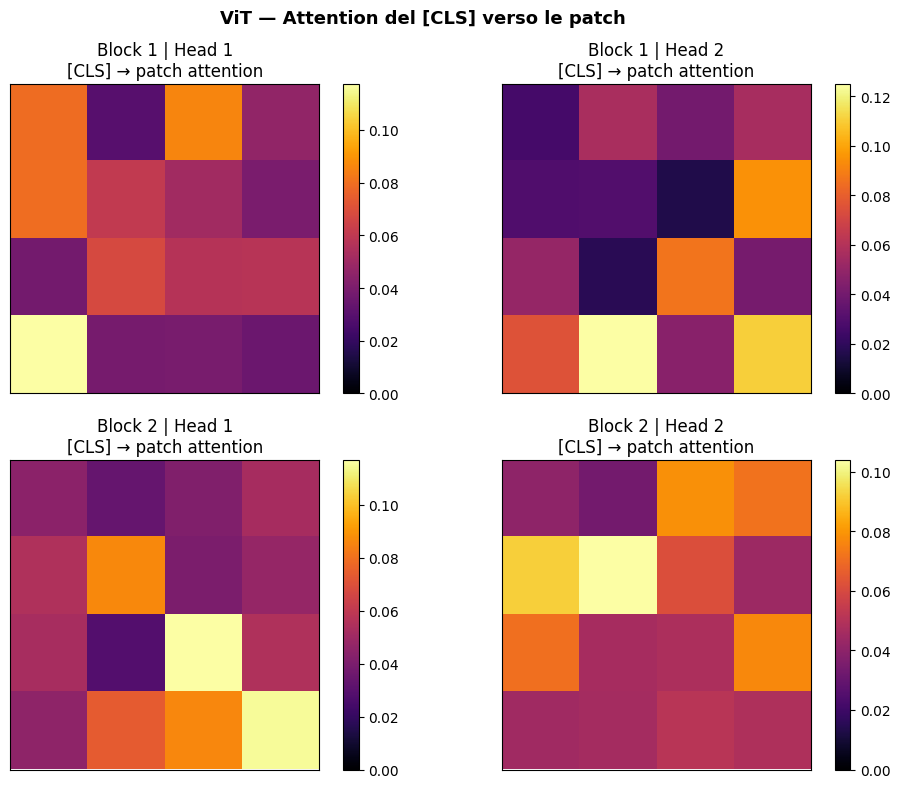

In [10]:
fig, axes = plt.subplots(L, num_heads, figsize=(5 * num_heads, 4 * L))

words = ["[CLS]"] + [f"P{i}" for i in range(N)]

for l in range(L):
    for h in range(num_heads):
        ax = axes[l, h]
        # Attenzione del [CLS] (riga 0) verso tutte le patch (colonne 1..N)
        cls_attn = all_weights[l][0, h, 0, 1:].detach().numpy().reshape(ph, pw)
        im = ax.imshow(cls_attn, cmap='inferno', vmin=0)
        ax.set_title(f"Block {l+1} | Head {h+1}\n[CLS] → patch attention")
        plt.colorbar(im, ax=ax)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("ViT — Attention del [CLS] verso le patch", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
